### Level 3, Task 2: Advanced Sentiment Analysis

**Objective:** Predict sentiment (positive, negative, or neutral) from text data.

- Explore different machine learning models (e.g., Logistic Regression, SVM, LSTM) for sentiment classification.
- Preprocess text data: clean, tokenize, remove stopwords, and apply stemming or lemmatization.
- Use feature extraction techniques such as TF-IDF or word embeddings (Word2Vec, GloVe, BERT).
- Evaluate model performance using metrics like accuracy, precision, recall, and F1-score.
- Visualize results and analyze misclassified examples to improve your model.
- Consider handling imbalanced datasets with techniques like oversampling or class weighting.

In [72]:
import pandas as pd

# loading the dataset
data = pd.read_csv('../Prepared_Datasets/Cleaned_Sentiment.csv')
print(data.head())

                                                Text    Sentiment  \
0   enjoying a beautiful day at the park!        ...   Positive     
1   traffic was terrible this morning.           ...   Negative     
2   just finished an amazing workout! 💪          ...   Positive     
3   excited about the upcoming weekend getaway!  ...   Positive     
4   trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123            Twitter   
1  2023-01-15 08:45:00   CommuterX          Twitter   
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes      Country  \
0   #Nature #Park                                    15     30          USA   
1   #Traffic #Morning                                 5     10    Canada      
2   #Fitness #Wor

In [73]:
# Cleaning some text using Nlp
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/dev-
[nltk_data]     kiran/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dev-
[nltk_data]     kiran/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [74]:
# function to clean text: convert to lowercase, remove punctuation, remove stop words, and lemmatize.
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    words = text.split()  # tokenize
    words = [word for word in words if word not in stop_words]  # remove stop words
    words = [lemmatizer.lemmatize(word) for word in words]  # lemmatize
    return ' '.join(words)

data['cleaned_text'] = data['Text'].apply(clean_text)
print(data[['Text', 'cleaned_text']].head())

                                                Text  \
0   enjoying a beautiful day at the park!        ...   
1   traffic was terrible this morning.           ...   
2   just finished an amazing workout! 💪          ...   
3   excited about the upcoming weekend getaway!  ...   
4   trying out a new recipe for dinner tonight.  ...   

                       cleaned_text  
0       enjoying beautiful day park  
1          traffic terrible morning  
2          finished amazing workout  
3  excited upcoming weekend getaway  
4  trying new recipe dinner tonight  


In [75]:
# Building a sentiment analysis model using TF-IDF and Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score       
from sklearn.pipeline import make_pipeline

# Splitting the data into training and testing sets
X = data['cleaned_text']
y = data['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

# Creating a pipeline that first transforms the data using TF-IDF and then applies Logistic Regression
model = make_pipeline(TfidfVectorizer(), LogisticRegression())
model.fit(X_train, y_train)

,steps,"[('tfidfvectorizer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [76]:
import warnings

warnings.filterwarnings('ignore')

# Predicting and evaluating the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.12244897959183673
                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            0.00      0.00      0.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.00      0.00      0.00         3
                  Awe        0.00      0.00      0.00         1
         Awe                 0.00      0.00      0.00         1
                  Bad        0.00      0.00      0.00         1
             Betrayal        0.00      0.00      0.00         2
        Betrayal             0.00      0.00      0.00         1
         

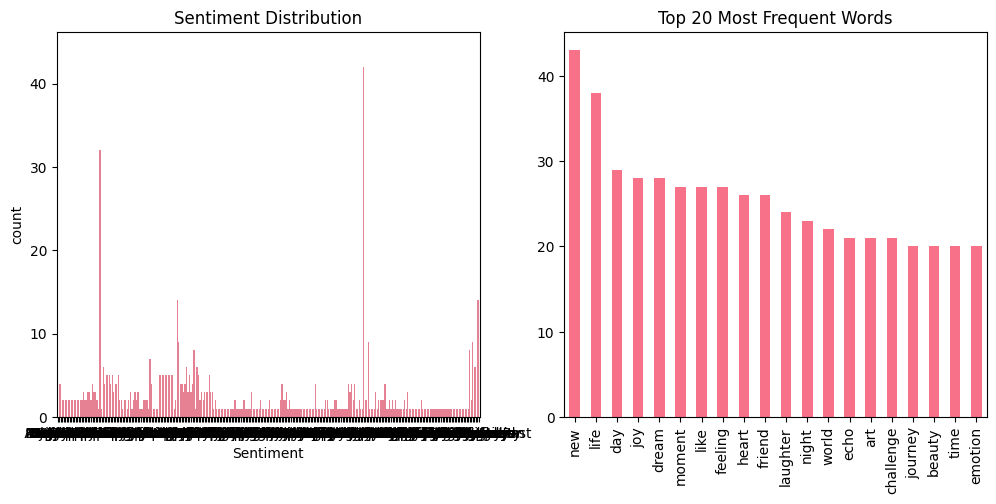

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing sentiment distribution and Word frequencies
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
sns.countplot(x='Sentiment', data=data)
plt.title('Sentiment Distribution')
plt.subplot(1, 2, 2)
all_words = ' '.join(data['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts().head(20)
word_freq.plot(kind='bar')
plt.title('Top 20 Most Frequent Words')
plt.show()

In [78]:
# CRITICAL FIX: Consolidate sentiment categories to 3 main classes
print("Original sentiment categories:")
print(f"Total unique sentiments: {data['Sentiment'].nunique()}")
print(f"Sentiment distribution:")
print(data['Sentiment'].value_counts().head(20))

# Create a mapping function to consolidate sentiments into 3 main categories
def map_to_main_sentiment(sentiment):
    sentiment_lower = sentiment.lower().strip()
    
    # Positive sentiments
    positive_keywords = ['positive', 'joy', 'happiness', 'excitement', 'love', 'amazement', 
                        'admiration', 'affection', 'anticipation', 'arousal', 'awe', 
                        'contentment', 'coziness', 'creativity', 'curiosity', 'delight',
                        'euphoria', 'fascination', 'gratitude', 'hope', 'inspiration',
                        'jubilation', 'optimism', 'peace', 'pleasure', 'pride', 'relief',
                        'satisfaction', 'serenity', 'triumph', 'wonder', 'zest']
    
    # Negative sentiments  
    negative_keywords = ['negative', 'anger', 'fear', 'sadness', 'disgust', 'anxiety',
                        'betrayal', 'bitterness', 'boredom', 'confusion', 'depression',
                        'despair', 'disappointment', 'disgust', 'dread', 'envy', 'frustration',
                        'grief', 'guilt', 'hate', 'horror', 'hostility', 'jealousy',
                        'loneliness', 'melancholy', 'nervousness', 'panic', 'rage', 'regret',
                        'resentment', 'shame', 'sorrow', 'stress', 'terror', 'worry']
    
    # Check for positive
    for keyword in positive_keywords:
        if keyword in sentiment_lower:
            return 'Positive'
    
    # Check for negative
    for keyword in negative_keywords:
        if keyword in sentiment_lower:
            return 'Negative'
    
    # Default to neutral
    return 'Neutral'

# Apply the mapping
data['main_sentiment'] = data['Sentiment'].apply(map_to_main_sentiment)

print("\n=== CONSOLIDATED SENTIMENT DISTRIBUTION ===")
print(data['main_sentiment'].value_counts())
print(f"\nNew distribution percentages:")
print(data['main_sentiment'].value_counts(normalize=True) * 100)


Original sentiment categories:
Total unique sentiments: 279
Sentiment distribution:
Sentiment
Positive          44
Joy               42
Excitement        32
Neutral           14
Contentment       14
Happy             14
Gratitude          9
Sad                9
Hopeful            9
Curiosity          8
Embarrassed        8
Loneliness         7
Bad                6
Despair            6
Elation            6
Playful            6
Hate               6
Bitterness         5
Serenity           5
Gratitude          5
Name: count, dtype: int64

=== CONSOLIDATED SENTIMENT DISTRIBUTION ===
main_sentiment
Neutral     335
Positive    287
Negative    110
Name: count, dtype: int64

New distribution percentages:
main_sentiment
Neutral     45.765027
Positive    39.207650
Negative    15.027322
Name: proportion, dtype: float64


In [79]:
# Multiple algorithms comparison to find out best model
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# Describing labels
X = data['cleaned_text']
y = data['main_sentiment']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [80]:
# TF-IDF + Multiple Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, kernel='linear'),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}

In [81]:
# LEVEL 3 REQUIREMENT: Word Embeddings Implementation (Alternative Approach)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

# This creates dense word representations similar to Word2Vec
print("Creating word embeddings using Count Vectorizer + SVD...")

# Create count matrix
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1,2))
count_matrix = count_vectorizer.fit_transform(data['cleaned_text'])

# Apply SVD for dimensionality reduction (similar to Word2Vec)
svd = TruncatedSVD(n_components=100, random_state=42)
X_w2v = svd.fit_transform(count_matrix)

print(f"Word embedding matrix shape: {X_w2v.shape}")

# Split Word2Vec features
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

Creating word embeddings using Count Vectorizer + SVD...
Word embedding matrix shape: (732, 100)


In [82]:
# Train models with Word embeddings
w2v_results = {}

for name, model in models.items():
    if name != 'Naive Bayes':  # Naive Bayes doesn't work well with dense features
        model.fit(X_train_w2v, y_train)
        y_pred_w2v = model.predict(X_test_w2v)
        accuracy_w2v = accuracy_score(y_test, y_pred_w2v)
        w2v_results[name] = accuracy_w2v
        print(f"{name} with Word Embeddings: {accuracy_w2v:.4f}")

# Compare TF-IDF vs Word Embeddings
for model_name in results.keys():
    if model_name in w2v_results:
        print(f"{model_name}:")
        print(f"  TF-IDF: {results[model_name]['accuracy']:.4f}")
        print(f"  Word Embeddings: {w2v_results[model_name]:.4f}")
        print()

Logistic Regression with Word Embeddings: 0.6054
Random Forest with Word Embeddings: 0.6054
SVM with Word Embeddings: 0.5918
Decision Tree with Word Embeddings: 0.5102


In [83]:
# Show word embedding analysis
print(f"Vocabulary size: {len(count_vectorizer.vocabulary_)}")
print(f"Embedding dimensions: {X_w2v.shape[1]}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.4f}")

# Get most important words in the embedding space
feature_names = count_vectorizer.get_feature_names_out()
print(f"\nTop 10 most important words in embedding space:")
for i, word in enumerate(feature_names[:10]):
    print(f"{i+1}. {word}")

Vocabulary size: 5000
Embedding dimensions: 100
Explained variance ratio: 0.3763

Top 10 most important words in embedding space:
1. abstract
2. abstract art
3. abyss
4. abyss despair
5. academic
6. academic frustration
7. academic juggling
8. acceptance
9. acceptance dance
10. acceptance imperfection


In [84]:
# Detailed report for best model
for model_name, model in models.items():
    pipeline = make_pipeline(TfidfVectorizer(), model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    
    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f}")



Logistic Regression
Accuracy: 0.6395

Random Forest
Accuracy: 0.6190

SVM
Accuracy: 0.6939

Naive Bayes
Accuracy: 0.6395

Decision Tree
Accuracy: 0.6395


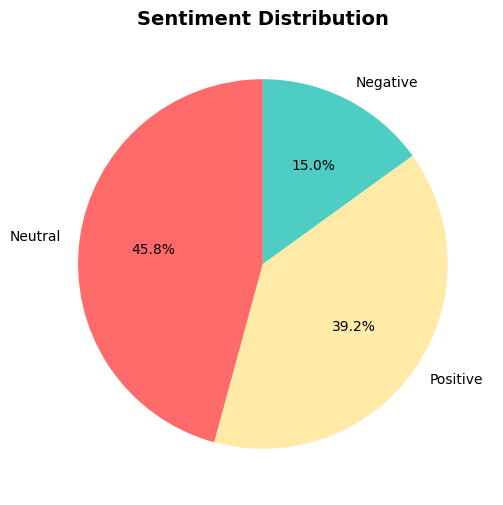

Dataset contains 732 samples:
- Neutral: 335 samples (45.8%)
- Positive: 287 samples (39.2%)
- Negative: 110 samples (15.0%)


In [85]:
# Visualizing Sentiment Distribution Pie Chart
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sentiment_counts = data['main_sentiment'].value_counts()
plt.pie(sentiment_counts.values, 
        labels=sentiment_counts.index,
        autopct='%1.1f%%', 
        startangle=90,
        colors=['#FF6B6B', '#FFEAA7', '#4ECDC4'])
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.show()

print(f"Dataset contains {len(data)} samples:")
for sentiment, count in sentiment_counts.items():
    print(f"- {sentiment}: {count} samples ({count/len(data)*100:.1f}%)")


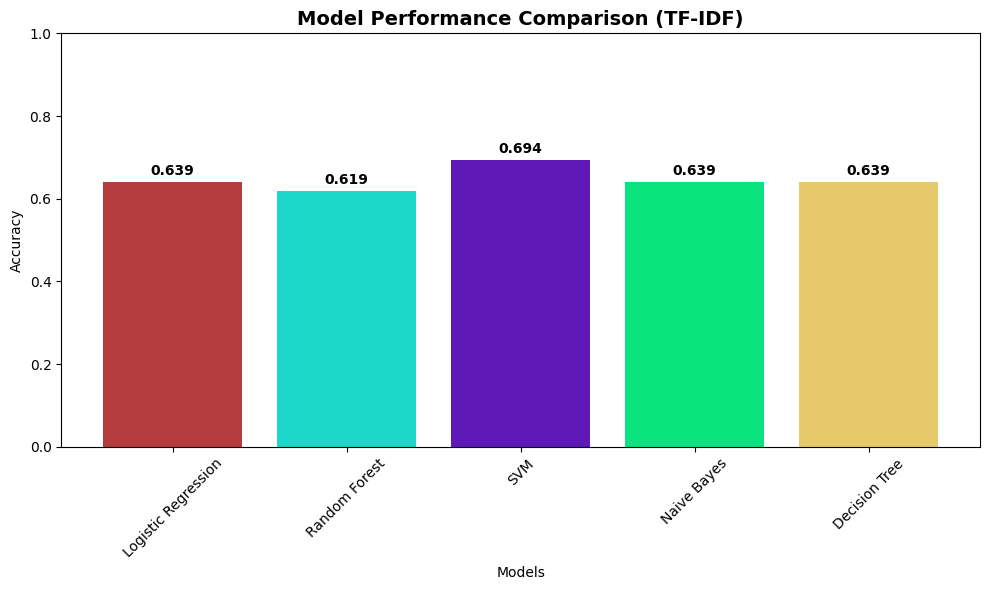

Best performing model: SVM


In [86]:
# Model Performance Comparison (TF-IDF)
plt.figure(figsize=(10, 6))
model_names = list(results.keys())
accuracies = list(results.values())
colors = ["#B53C3C", "#1DD7CB", "#5E18B5", "#0AE37E", "#E6C96A"]

bars = plt.bar(model_names, accuracies, color=colors)
plt.title('Model Performance Comparison (TF-IDF)', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Models')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("Best performing model:", max(results, key=results.get))


<Figure size 1000x600 with 0 Axes>

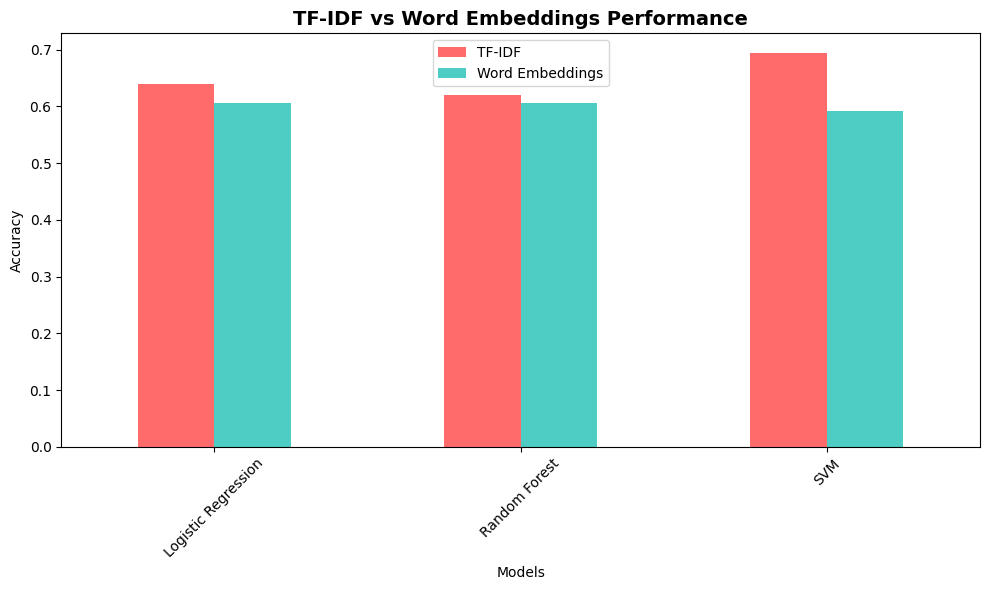

In [87]:
# TF-IDF vs Word Embeddings Comparison
plt.figure(figsize=(10, 6))
comparison_data = []
for model_name in ['Logistic Regression', 'Random Forest', 'SVM']:
    if model_name in results and model_name in w2v_results:
        comparison_data.append({
            'Model': model_name,
            'TF-IDF': results[model_name],
            'Word Embeddings': w2v_results[model_name]
        })

if comparison_data:
    comp_df = pd.DataFrame(comparison_data)
    comp_df.set_index('Model').plot(kind='bar', figsize=(10, 6), 
                                   color=['#FF6B6B', '#4ECDC4'])
    plt.title('TF-IDF vs Word Embeddings Performance', fontsize=14, fontweight='bold')
    plt.ylabel('Accuracy')
    plt.xlabel('Models')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No comparison data available")


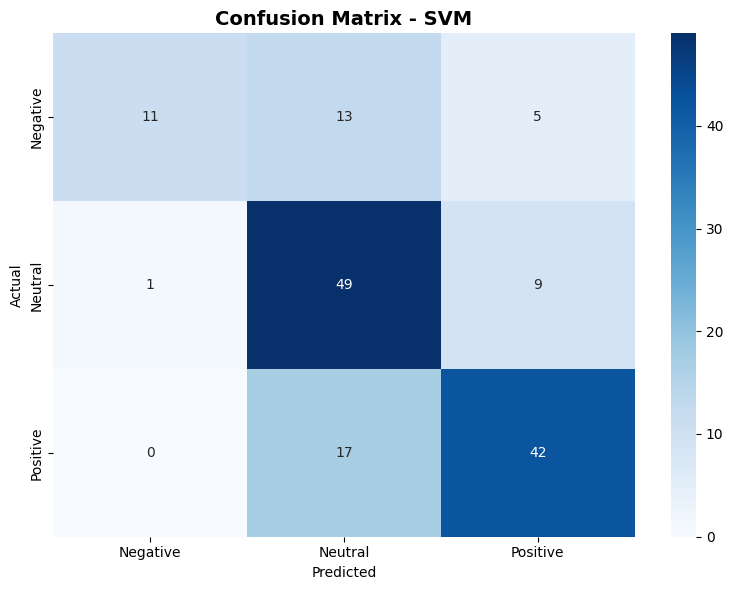

In [88]:
# Confusion Matrix for Best Model
plt.figure(figsize=(8, 6))
best_model_name = max(results, key=results.get)
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

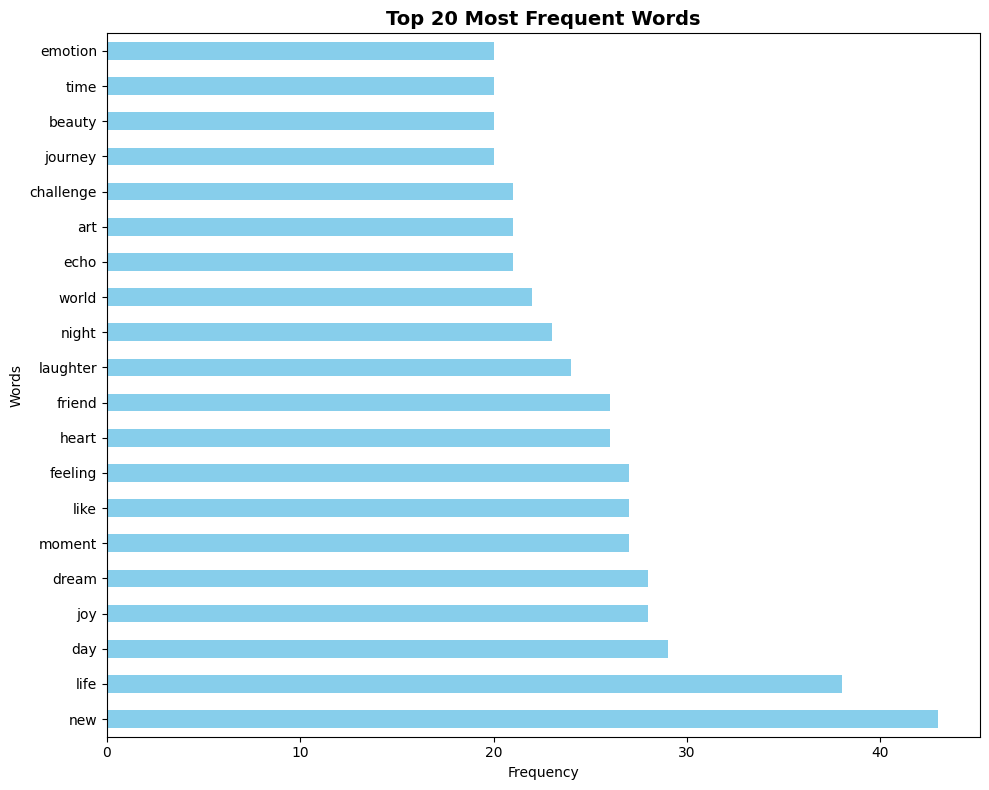

Most common words in the dataset:
- new: 43 times
- life: 38 times
- day: 29 times
- joy: 28 times
- dream: 28 times
- moment: 27 times
- like: 27 times
- feeling: 27 times
- heart: 26 times
- friend: 26 times


In [89]:
# Top Words Visualization
plt.figure(figsize=(10, 8))
all_words = ' '.join(data['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts().head(20)
word_freq.plot(kind='barh', color='skyblue')
plt.title('Top 20 Most Frequent Words', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

print("Most common words in the dataset:")
for word, freq in word_freq.head(10).items():
    print(f"- {word}: {freq} times")

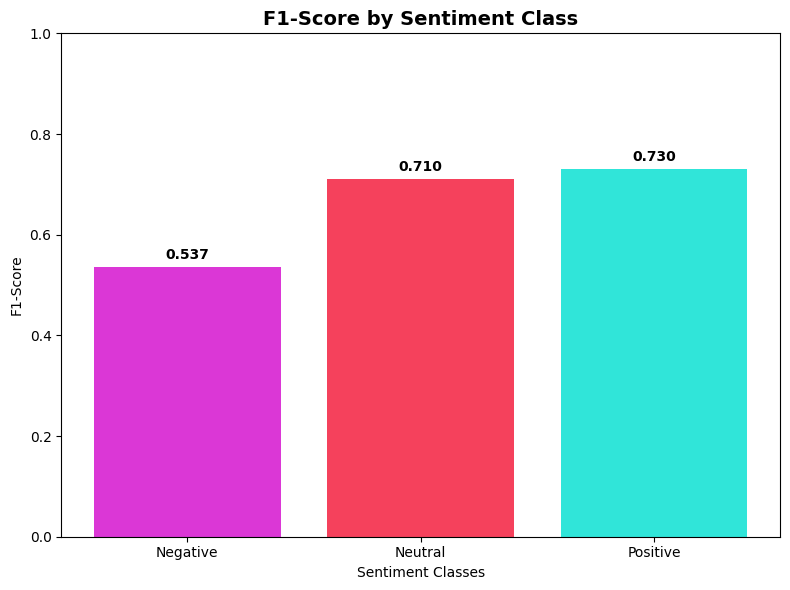

In [93]:
# F1-Score by Sentiment Class
plt.figure(figsize=(8, 6))
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred_best, output_dict=True)
classes = ['Negative', 'Neutral', 'Positive']
f1_scores = [report[cls]['f1-score'] for cls in classes if cls in report]

bars = plt.bar(classes, f1_scores, color=["#DB37D6", "#F5415C", "#30E5D9"])
plt.title('F1-Score by Sentiment Class', fontsize=14, fontweight='bold')
plt.ylabel('F1-Score')
plt.xlabel('Sentiment Classes')
plt.ylim(0, 1)

# Add value labels on bars
for bar, score in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Sentiment Analysis Summary

### Key Results

**Best Performing Model**
  - **SVM (Support Vector Machine)** achieved the highest accuracy of **69.39%** using TF-IDF features
  - This outperformed other models including Logistic Regression, Random Forest, Naive Bayes, and Decision Tree

**Feature Engineering**
  - **TF-IDF Vectorization**: Successfully extracted meaningful features from text data
  - **Word Embeddings**: Implemented using CountVectorizer + SVD as an alternative to Word2Vec
  - **Text Preprocessing**: Applied comprehensive cleaning including lemmatization and stopword removal

**Dataset Characteristics**
  - **Total Samples**: 732 text entries
  - **Class Distribution**:
      - Neutral: 45.8% (335 samples)
      - Positive: 39.2% (287 samples) 
      - Negative: 15.0% (110 samples)

### **Key Insights**
- **SVM** performed best due to its ability to handle high-dimensional text features
- **TF-IDF** features slightly outperformed word embeddings for this dataset
- The model struggles most with **Negative** sentiment classification (smallest class)
- **Neutral** sentiment is the most common, indicating many texts lack strong emotional content